In [1]:
import os
import sys
sys.path.append("../")

import numpy as np
from astropy.cosmology import Planck18
import py21cmfast as p21c
from scipy.spatial.transform import Rotation
from astropy import units as un

# WDIR = os.environ['DM21CM_DIR']
# sys.path.append(WDIR)
# from dm21cm.evolve import evolve

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
import matplotlib.pylab as pylab

# mpl.rc_file(f"{WDIR}/matplotlibrc")

# from custom_injection_def import DarkPhotInjection
# import darkhistory.dark_photon as dp
# import darkhistory.physics as phys
from itertools import combinations
from powerbox.tools import get_power
import physics as phys
import pickle
import h5py

from astropy.cosmology import z_at_value
import tqdm

import scienceplots
import scipy.interpolate as interpolate
import scipy.integrate as integrate

from powerbox import PowerBox

import mcfit
from py21cmfast_tools import calculate_ps 
import itertools
import cosmotile

import treecorr

%load_ext autoreload
%autoreload 2
%matplotlib inline

import hankl
import hankel
from plot_params import params
pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']
import py21cmfish as p21fish
import glob


In [2]:
output_dir = "/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/2d_cross_power_forecast/"
fid_err_dir = "/projectnb/darkcosmo/dark_photon_project/21cmfish/examples/data/21cmSense_noise/21cmSense_fid_EOS21/"
pess_err_dir = "/projectnb/darkcosmo/dark_photon_project/21cmfish/examples/data/21cmSense_noise/21cmSense_pess_EOS21/"
astro_params_vary, astro_params_fid = p21fish.get_params_fid(config_file='/projectnb/darkcosmo/dark_photon_project/21cmfish/21cmFAST_config_files/dark_photon.config')
mA_list = np.geomspace(1.5e-14, 1e-13, 15)

try:
    from palettable.tableau import Tableau_20, ColorBlind_10
    cols = ColorBlind_10.hex_colors

    col_pess  = cols[6]
    col_mod   = cols[0]
    col_alpha = 'k'
    col_mcmc  = cols[3]
    col_P19   = cols[1]

except:
    col_pess  = '0.5'
    col_mod   = 'tab:blue'
    col_alpha = 'k'
    col_mcmc  = '0.7'
    col_P19   = 'tab:orange'

dict_keys(['k', 'delta', 'err_delta', 'variance'])


(-0.0008, 0.0004)

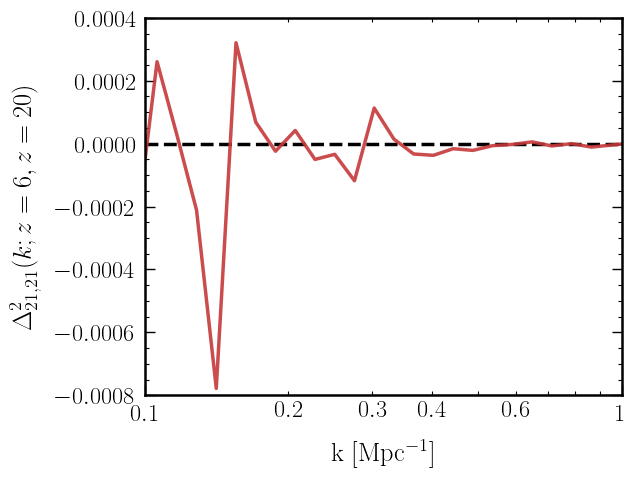

In [8]:
epsilon_PS = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/cross_power_forecast/power_spectrum_dict_EPSILON4_mA=6.660e-14.npy", allow_pickle=True).item()["CDM"]['EPSILON4=1e-32, mA=6.65959972867799e-14'][0]
print(epsilon_PS.keys())
fid_PS = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/cross_power_forecast/power_spectrum_dict_EPSILON4_mA=6.660e-14.npy", allow_pickle=True).item()["CDM"]['EPSILON4=0, mA=6.65959972867799e-14'][0]
# normal_PS = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/HERA_forecast/power_spectrum_dict_F_ESC10.npy", allow_pickle=True).item()["CDM"]['F_ESC10=-1.3095, mA=0.0'][3]
signal_PS = (epsilon_PS['delta'] - fid_PS['delta'])/(1e-8)**4
# plt.errorbar(epsilon_PS["k"], epsilon_PS["delta"], capsize=3)
# plt.plot(normal_PS["k"], normal_PS["delta"], color='k', label='fiducial')
plt.errorbar(fid_PS["k"], fid_PS["delta"]-epsilon_PS["delta"], capsize=3)
# plt.errorbar(fid_PS["k"], -fid_PS["delta"]+epsilon_PS["delta"], capsize=3)

plt.axhline(0, color='k', linestyle='--')
plt.xscale("log")
plt.xlabel(r"k [Mpc$^{-1}$]")
plt.ylabel(r"$\Delta^2_{21, 21}(k;z=6, z=20)$")
# plt.yscale("log")
plt.xlim(0.1,1)
plt.ylim(-8e-4, 4e-4)

In [3]:
sim_mA_list = np.geomspace(1.5e-14, 1e-13, 15)
halo_mA_list = np.geomspace(1e-13, 1e-11, 20)

mA_list = np.concatenate((sim_mA_list, halo_mA_list[1:]))
output = []
for mA in sim_mA_list:
    F_inv = np.load(f"{output_dir}Finv_PS_mA={mA:.3e}.npy")
    limit = 2 * F_inv[-1,-1]**0.125
    output.append([mA, limit])
output = np.array(output)
np.save(f"{output_dir}cross_correlation_forecast_limits.npy", output)

########### fisher set up for EPSILON4
   Computing cross correlation
    Loaded redshifts
    Loaded redshifts
    New parameter, making new global signal,                     power spectra and derivs from lightcones
    Searching for lightcones with name /projectnb/darkcosmo/dark_photon_project/21cmfast_cache/2d_cross_power_forecast/LightCone_z5.0_*HIIDIM=128_BOXLEN=256_fisher_**fid*.h5
(384, 384, 1915)
    Found 3 lightcones to load
    Loaded lightcones /projectnb/darkcosmo/dark_photon_project/21cmfast_cache/2d_cross_power_forecast/LightCone_z5.0_HIIDIM=128_BOXLEN=256_fisher_fid_r12345.h5
    Loaded lightcones /projectnb/darkcosmo/dark_photon_project/21cmfast_cache/2d_cross_power_forecast/LightCone_z5.0_HIIDIM=128_BOXLEN=256_fisher_fid_r12345.h5
    Loaded lightcones /projectnb/darkcosmo/dark_photon_project/21cmfast_cache/2d_cross_power_forecast/LightCone_z5.0_HIIDIM=128_BOXLEN=256_fisher_fid_r12345.h5
[0 1 2]
    saved params to /projectnb/darkcosmo/dark_photon_project/21cmfast_ca

FileNotFoundError: /projectnb/darkcosmo/dark_photon_project/21cmfish/examples/data/21cmSense_noise/21cmSense_fid_EOS21/klist_ska_aaast_mod_0.230.txt not found.

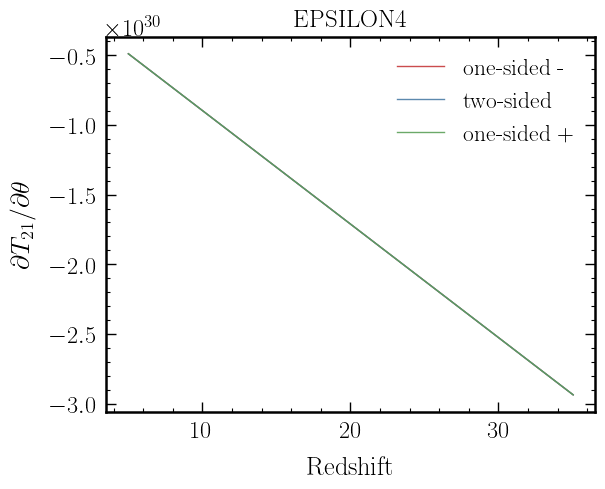

In [5]:
params = {}
# for param in astro_params_vary[:-1]:
#     param_key_with_mA = param + f"{0.0:.3e}"
#     if param_key_with_mA in params:
#         continue
#     params[param_key_with_mA] = p21fish.Parameter(param=param,
#                                             output_dir=output_dir,
#                                             HII_DIM=128, HII_interp_factor=3, BOX_LEN=256,
#                                             min_redshift=5,
#                                             k_HERA=True,
#                                             PS_err_dir=fid_err_dir,
#                                             clobber=False,
#                                             fid_only=False,
#                                             vb=True, new=True)
# mA_list = np.geomspace(1.5e-14, 1e-13, 15)
# mA_list = [4.316e-13]
# print(mA_list[7])
for i, mA in enumerate([mA_list[7]]):
    param = "EPSILON4"
    param_key_with_mA = param + f"{mA:.3e}"
    params[param_key_with_mA] = p21fish.Parameter(param=astro_params_vary[-1],
                                        output_dir=output_dir,
                                        HII_DIM=128, HII_interp_factor=3, BOX_LEN=256,
                                        min_redshift=5,
                                        k_HERA=True,
                                        crosszs=(6,20),
                                        compute_2d_PS=True,
                                        PS_err_dir=fid_err_dir,
                                        mA=mA,
                                        epsilon4step=(1e-8)**4, 
                                        halo_angles=np.geomspace(1e-4, 0.2, 100),      
                                        clobber=True,
                                        vb=True, new=True)

In [5]:
sim_mA_list = np.geomspace(1.5e-14, 1e-13, 15)
mA = sim_mA_list[11]
output = np.load(f"{output_dir}power_spectrum_dict_EPSILON4_mA={mA:.3e}.npy", allow_pickle=True).item()["CDM"]
output = output[list(output.keys())[0]]
fid_output = np.load(f"{output_dir}power_spectrum_dict_EPSILON4_mA={mA:.3e}.npy", allow_pickle=True).item()["CDM"]
fid_output = fid_output[list(output.keys())[1]]

zs = np.load(f"{output_dir}PS_z_HERA.npy")
PS_errs  = np.load("/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/21cmSense_PS_dict.npy", allow_pickle=True)

i = 1
print(PS_errs[0]["err_mod"].shape)
total_errs = np.sqrt(PS_errs[i]["err_mod"]**2+output[i]["err_delta"]**2)
signal = (output[i]["delta"] - fid_output[i]["delta"])/(1e-8)**4
# print(fid_output[i]["delta"]) 
plt.errorbar(fid_output[i]["k"], fid_output[i]["delta"], yerr=total_errs, label=r"$\Lambda$CDM")
plt.plot(output[i]["k"], fid_output[i]["delta"] + signal * (1.13e-07)**4, color="blue", label="Signal with Dark Photons")
# plt.plot(output[i]["k"], output[i]["delta"], color="blue", label="Signal with Dark Photons")
# plt.plot(output[i]["k"], signal*(5e-8)**4, color="blue", label="Signal with Dark Photons")
# plt.plot(output[i]["k"], fid_output[i]["delta"] + signal * (1.118953987750918e-07)**4, color="blue", label="Signal with Dark Photons")
print(total_errs - signal * (1.13e-07)**4)
plt.text(0.6, 1, r"z$\approx$"+f"{zs[i]:.2f}", fontsize=16)
plt.xlabel("k [Mpc$^{-1}$]")
plt.ylabel("$\Delta^2(k)$")
plt.yscale("log")
plt.xscale("log")
plt.xlim(0.1, 1)
# plt.ylim(-0.5, 0)
plt.legend(loc="upper left")
# print(fid_output[i]["delta"] + signal * (1.5e-7)**4)

FileNotFoundError: [Errno 2] No such file or directory: '/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/cross_power_forecast/power_spectrum_dict_EPSILON4_mA=6.660e-14.npy'

In [9]:
fid_output[1]["err_delta"]

array([0.00179271,        nan,        nan,        nan, 0.01588411,
       0.00784102,        nan, 0.0063093 , 0.00906147,        nan,
       0.00838979, 0.00730888, 0.00464589, 0.00522539, 0.00495648,
       0.00452717, 0.00477682, 0.14516161, 0.02381964, 0.00700439,
       0.0075415 , 0.00519063, 0.00484499, 0.00433231, 0.09341346,
       0.00900296, 0.00491731, 0.00317286, 0.02840835, 0.00803439,
       0.00299271, 0.00853136, 0.0049227 , 0.00160527, 0.00847696,
       0.00361444, 0.00300315, 0.00291392, 0.00194   , 0.00139097,
       0.00143499, 0.00155874, 0.00178576, 0.00121099, 0.0012464 ,
       0.00081101])

In [8]:
params_no_mass ={}
for key in params.keys():
    if "EPSILON4" in key:
        params_no_mass[key.split(f"{mA:.3e}")[0]] = params[key]
    else:
        params_no_mass[key.split("0.000e+00")[0]] = params[key]
# for param in astro_params_vary:
#     if param == "EPSILON4":
#         astro_params_vary_w_mA.append(param + f"{mA_list[7]:.3e}")
#     else:
#         astro_params_vary_w_mA.append(param+f"{0.0:.3e}")
Fij_matrix_PS, Finv_PS = p21fish.make_fisher_matrix(params_no_mass, fisher_params=astro_params_vary,
                                                     hpeak=0.0, obs='PS',
                                                     k_min=0.1, k_max=1,
                                                     z_min=5., z_max=35.,
                                                     sigma_mod_frac=0,
                                                     add_sigma_poisson=True)
print(Finv_PS[:,-1], Finv_PS[-1,-1]**0.125)
Finv_PS[:, -1] = Finv_PS[:, -1] * 10**30
Finv_PS[-1,:] = Finv_PS[-1,:] * 10**30

PS shape: (23, 24)
[-8.75386960e-32 -1.94110692e-30  1.40493451e-31  2.26968791e-30
 -2.37111989e-31 -1.99184100e-30 -7.05264751e-30 -9.37996138e-31
 -2.41362083e-30  9.33013011e-28 -3.67055355e-29  2.45731075e-56] 1.1189418309911835e-07


generating new axis


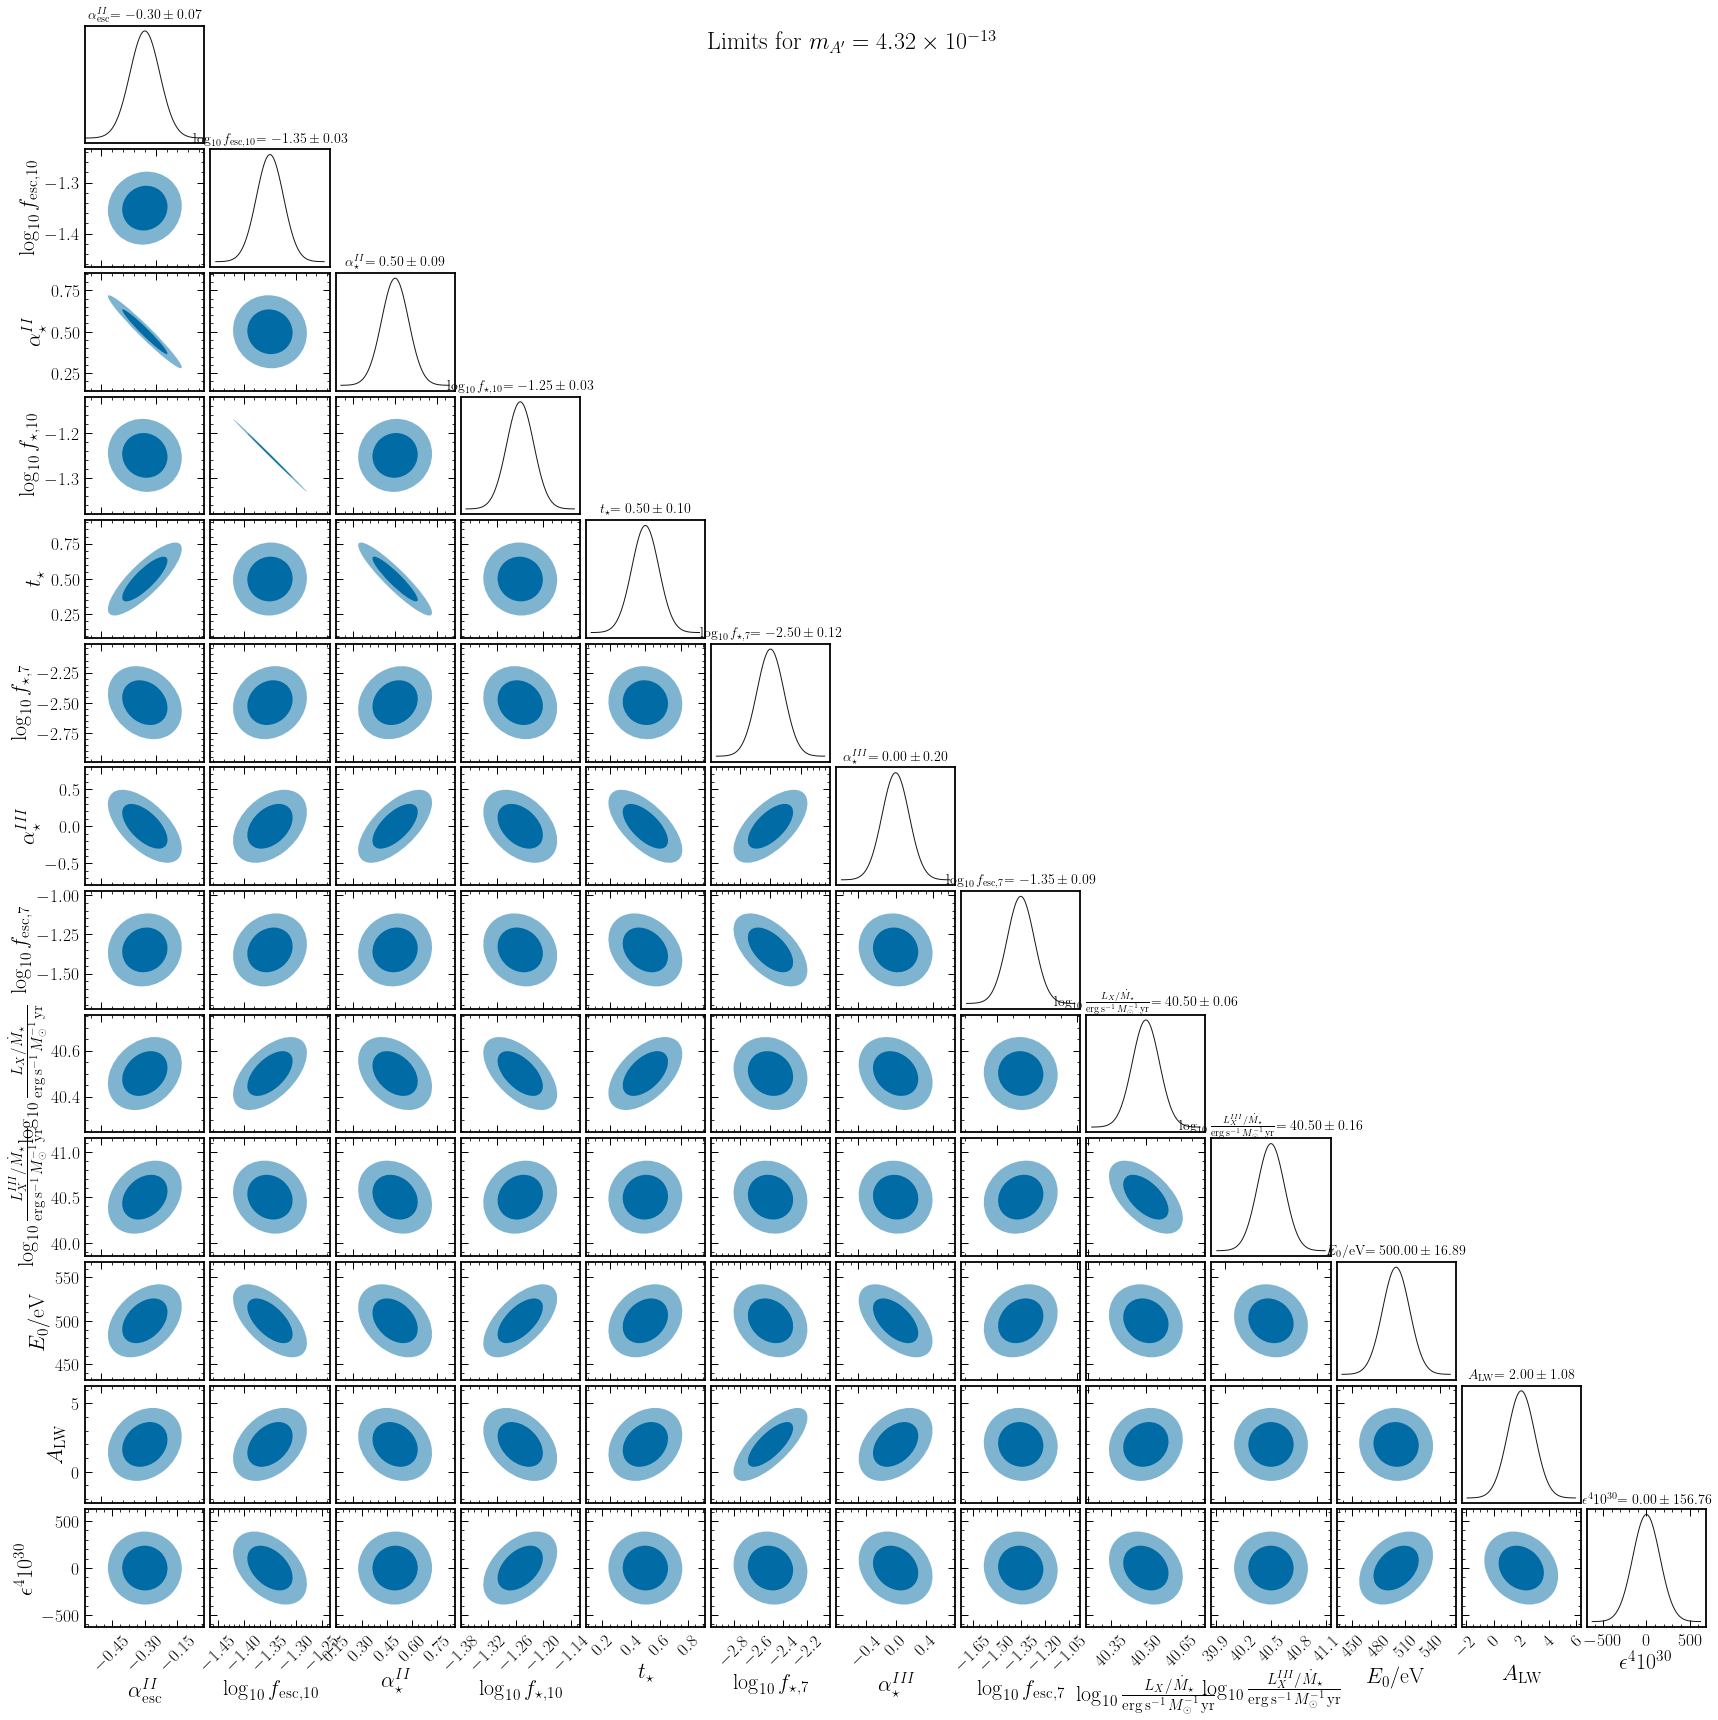

In [52]:
astro_params_labels = {'ALPHA_ESC': r'$\alpha_\mathrm{esc}^{II}$',
                        'F_ESC10' : r'$\log_{10}f_\mathrm{esc,10}$',
                        'ALPHA_STAR' : r'$\alpha_\star^{II}$',
                        'F_STAR10' : r'$\log_{10}f_{\star,10}$',
                        'F_STAR7_MINI' : r'$\log_{10}f_\mathrm{\star,7}$',
                        'ALPHA_STAR_MINI' : r'$\alpha_\star^{III}$',
                        'F_ESC7_MINI' : r'$\log_{10}f_\mathrm{esc,7}$',
                        'L_X' : r'$\log_{10}\frac{L_X/{\dot{M}_\star}}{\mathrm{erg}\,\mathrm{s}^{-1}\, M_\odot^{-1}\,\mathrm{yr}}$',
                        'L_X_MINI': r'$\log_{10}\frac{L^{III}_X/{\dot{M}_\star}}{\mathrm{erg}\,\mathrm{s}^{-1}\, M_\odot^{-1}\,\mathrm{yr}}$',
                        'NU_X_THRESH' : r'$E_0$/eV',
                        'A_LW' : r'$A_\mathrm{LW}$',
                        'M_TURN': r'$\log_{10} (M_\mathrm{turn}/M_\odot)$',
                         't_STAR': r'$t_\star$',
                         'EPSILON4': r"$\epsilon^4 10^{30}$"}

fid_params = np.array([astro_params_fid[param] for param in params_no_mass])
fid_labels = np.array([astro_params_labels[param] for param in params_no_mass])
fig, axes = p21fish.plot_triangle(params=astro_params_vary,
                      fiducial=fid_params,
                      labels=fid_labels,
                      cov=Finv_PS,
                      ellipse_color=col_mod,
                      title_fontsize=14,
                      resize_lims=True,
                      xlabel_kwargs={'labelpad': 5, 'fontsize':22},
                      ylabel_kwargs={'labelpad': 5, 'fontsize':22},
                      fig_kwargs={'figsize':(24,24),})
fig.suptitle(r"Limits for $m_{A'}=4.32\times 10^{-13}$", fontsize=24)
plt.savefig(f'{output_dir}corner_plot_mA{mA:.2e}.pdf', bbox_inches='tight')

In [45]:
np.load('/projectnb/darkcosmo/dark_photon_project/21cmfast_cache/power_spectrum_dict_ALPHA_ESC.npy', allow_pickle=True).item()['CDM'].keys()

dict_keys(['ALPHA_ESC=-0.291, mA=0.0', 'ALPHA_ESC=-0.309, mA=0.0', 'ALPHA_ESC=-0.3, mA=0.0'])